<a href="https://colab.research.google.com/github/fidhaashraf123/Dashboard/blob/main/Machine-learning/ML(Project).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**


With HadHeartAttack as the prediction variable, the task would involve using other features in the dataset to predict whether a patient has experienced a heart attack. This could be approached as a binary classification problem, where the model learns patterns from the other variables to predict the likelihood of HadHeartAttack (0 for no, 1 for yes).


Heart disease is one of the leading causes of mortality worldwide, with heart attacks being a primary manifestation. Early detection and intervention can significantly reduce the risk and improve patient outcomes. In this project, we aim to develop a predictive model that leverages patient demographic, health, and lifestyle information to determine the likelihood of a heart attack occurrence. By analyzing this data, healthcare providers may gain insights into high-risk patients, enabling proactive measures and better allocation of medical resources.

The objective is to predict whether a patient has had a heart attack (binary outcome: HadHeartAttack) based on a range of features, including medical history, lifestyle habits, and demographic details. This model could serve as an assistive tool in clinical decision-making and help in implementing preventive healthcare strategies.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Patients Data ( Used for Heart Disease Prediction ) (13).csv', encoding='latin-1')
df.head()

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0


In [ ]:
df.tail()

,ÿPatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
237625,237626,Puerto Rico,Female,Good,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,Not at all (right now),0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,Good,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,Not at all (right now),0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,Fair,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,Not at all (right now),1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,Very good,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,Never used e-cigarettes in my entire life,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1
237629,237630,Puerto Rico,Female,Good,Age 30 to 34,1.60,83.010002,32.419998,0,0,...,Never used e-cigarettes in my entire life,1,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df.isnull().sum()

,0
ÿPatientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


In [ ]:
df.duplicated().sum()

np.int64(0)

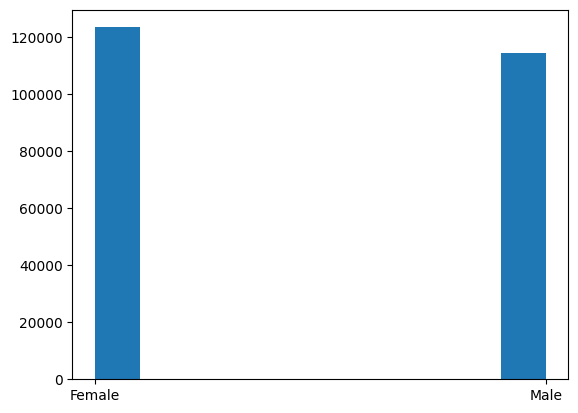

In [ ]:
plt.hist(df['Sex'])
plt.show()

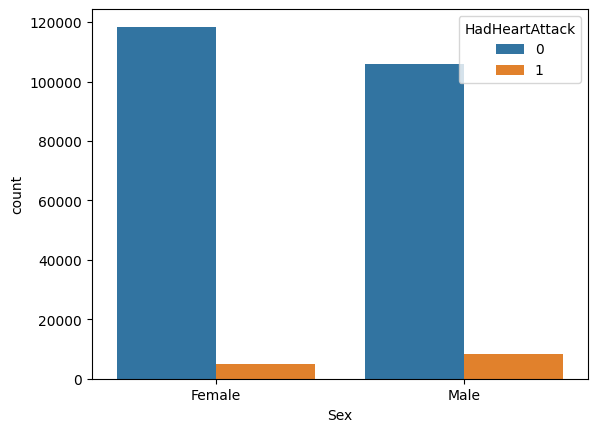

In [ ]:
sns.countplot(data=df, x='Sex',hue='HadHeartAttack')
plt.show()

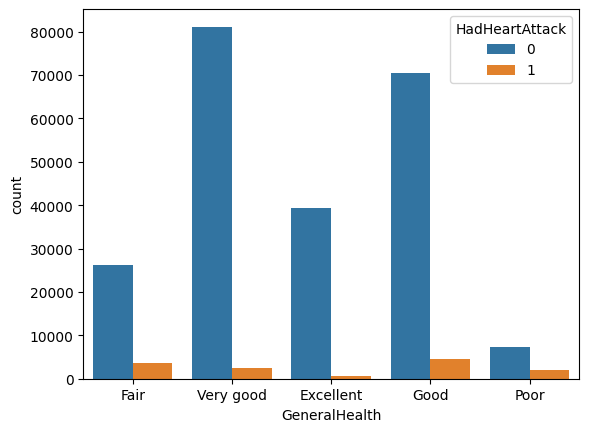

In [ ]:
sns.countplot(data=df, x='GeneralHealth',hue='HadHeartAttack')
plt.show()

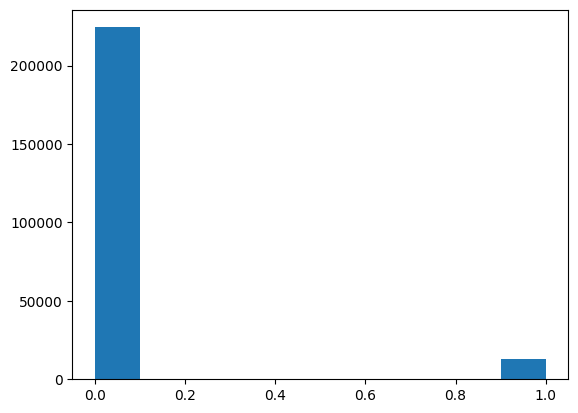

In [ ]:
plt.hist(df['HadHeartAttack'])
plt.show()

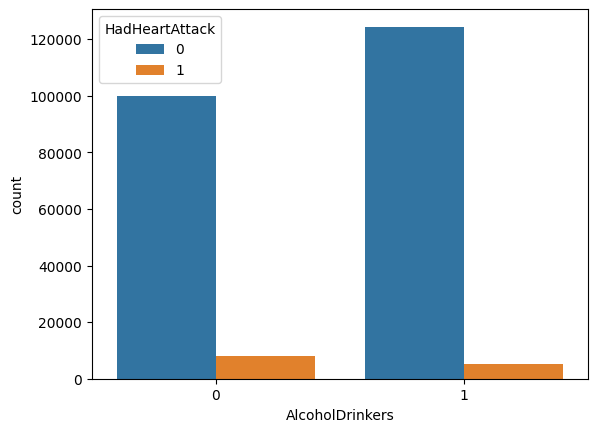

In [ ]:
sns.countplot(data=df, x='AlcoholDrinkers',hue='HadHeartAttack')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
print(df['AgeCategory'].unique())

['Age 75 to 79' 'Age 65 to 69' 'Age 60 to 64' 'Age 70 to 74'
 'Age 50 to 54' 'Age 80 or older' 'Age 55 to 59' 'Age 25 to 29'
 'Age 40 to 44' 'Age 30 to 34' 'Age 35 to 39' 'Age 18 to 24'
 'Age 45 to 49']


In [ ]:
print(df['GeneralHealth'].unique())

['Fair' 'Very good' 'Excellent' 'Good' 'Poor']


**replacing ordinal data**

In [ ]:
df['GeneralHealth'].replace(['Poor','Fair','Good','Very good','Excellent'],[0,1,2,3,4],inplace=True)

/tmp/ipykernel_33708/2154511816.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GeneralHealth'].replace(['Poor','Fair','Good','Very good','Excellent'],[0,1,2,3,4],inplace=True)
/tmp/ipykernel_33708/2154511816.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['GeneralHealth'].replace(['P

In [ ]:
df['AgeCategory'].replace(['Age 18 to 24','Age 25 to 29','Age 30 to 34','Age 35 to 39','Age 40 to 44','Age 45 to 49','Age 50 to 54','Age 55 to 59','Age 60 to 64','Age 65 to 69','Age 70 to 74','Age 75 to 79','Age 80 or older',],[0,1,2,3,4,5,6,7,8,9,10,11,12],inplace=True)

/tmp/ipykernel_33708/2123558647.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AgeCategory'].replace(['Age 18 to 24','Age 25 to 29','Age 30 to 34','Age 35 to 39','Age 40 to 44','Age 45 to 49','Age 50 to 54','Age 55 to 59','Age 60 to 64','Age 65 to 69','Age 70 to 74','Age 75 to 79','Age 80 or older',],[0,1,2,3,4,5,6,7,8,9,10,11,12],inplace=True)
/tmp/ipykernel_33708/2123558647.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explic

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['State']=le.fit_transform(df['State'])
df['Sex']=le.fit_transform(df['Sex'])
df['HadDiabetes']=le.fit_transform(df['HadDiabetes'])
df['SmokerStatus']=le.fit_transform(df['SmokerStatus'])
df['ECigaretteUsage']=le.fit_transform(df['ECigaretteUsage'])
df['RaceEthnicityCategory']=le.fit_transform(df['RaceEthnicityCategory'])
df['TetanusLast10Tdap']=le.fit_transform(df['TetanusLast10Tdap'])



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ÿPatientID                 237630 non-null  int64  
 1   State                      237630 non-null  int64  
 2   Sex                        237630 non-null  int64  
 3   GeneralHealth              237630 non-null  int64  
 4   AgeCategory                237630 non-null  int64  
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Features and target
X = df.drop('HadHeartAttack', axis=1)
y = df['HadHeartAttack']

# Apply SMOTE
smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X, y)

# Combine into one dataframe
df_smote = pd.concat(
    [pd.DataFrame(X_smote, columns=X.columns),
     pd.Series(y_smote, name='HadHeartAttack')],
    axis=1
)

print(df_smote.head())

   ÿPatientID  State  Sex  GeneralHealth  AgeCategory  HeightInMeters  \
0           1      0    0              1           11            1.63   
1           2      0    0              3            9            1.60   
2           3      0    1              4            8            1.78   
3           4      0    1              3           10            1.78   
4           5      0    0              2            6            1.68   

   WeightInKilograms        BMI  HadAngina  HadStroke  ...  ChestScan  \
0          84.820000  32.099998          1          0  ...          1   
1          71.669998  27.990000          0          0  ...          0   
2          71.209999  22.530001          0          0  ...          0   
3          95.250000  30.129999          0          0  ...          0   
4          78.019997  27.760000          0          0  ...          1   

   RaceEthnicityCategory  AlcoholDrinkers  HIVTesting  FluVaxLast12  \
0                      4                0          

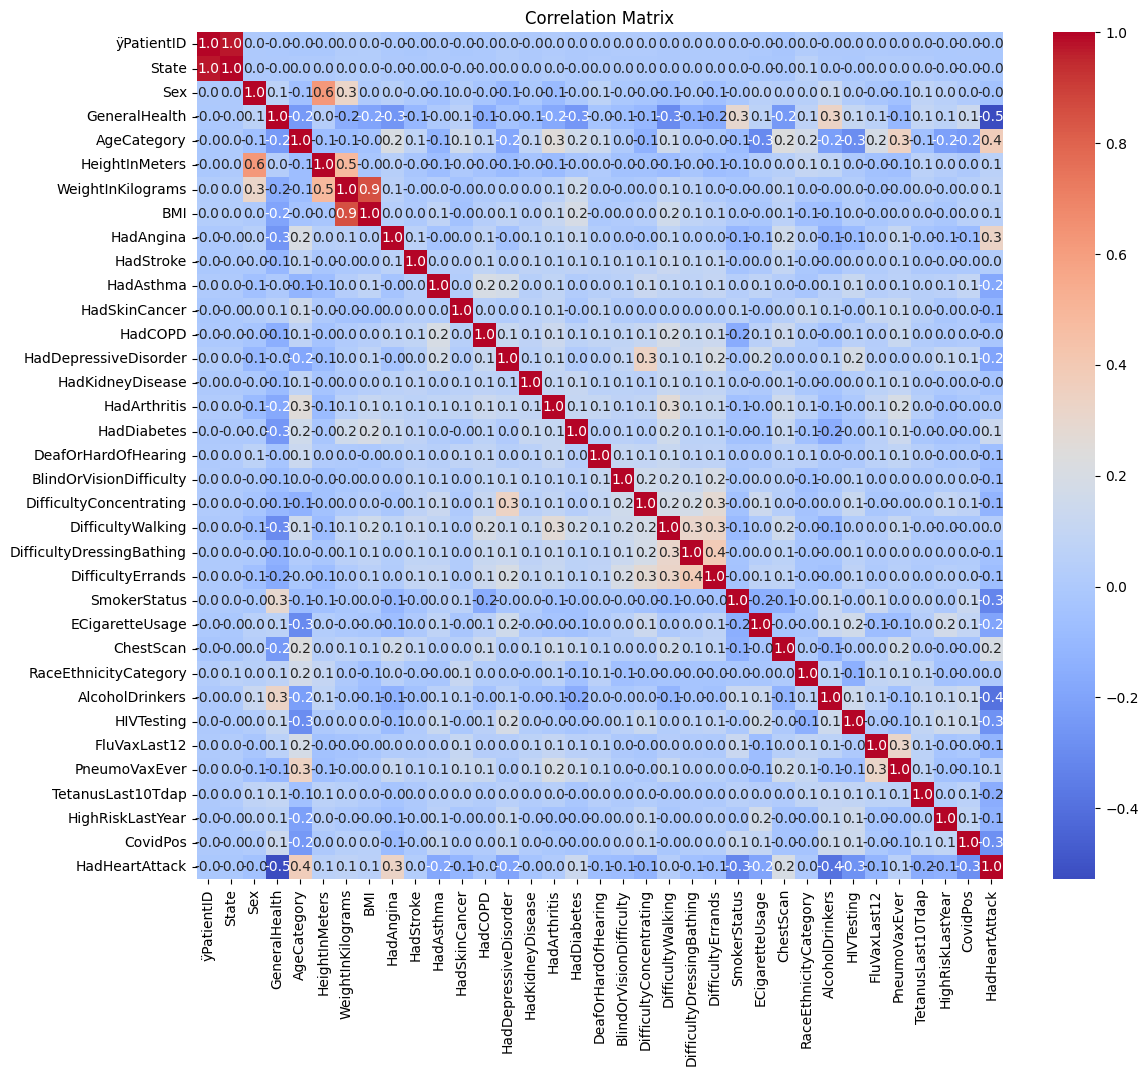

In [ ]:
corr_matrix=df_smote.corr()
plt.figure(figsize=(13,11))
sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
df_smote.drop(['State','BMI','WeightInKilograms','ÿPatientID','HeightInMeters'],axis=1,inplace=True)

In [ ]:
df_smote.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448858 entries, 0 to 448857
Data columns (total 30 columns):
 #   Column                     Non-Null Count   Dtype
---  ------                     --------------   -----
 0   Sex                        448858 non-null  int64
 1   GeneralHealth              448858 non-null  int64
 2   AgeCategory                448858 non-null  int64
 3   HadAngina                  448858 non-null  int64
 4   HadStroke                  448858 non-null  int64
 5   HadAsthma                  448858 non-null  int64
 6   HadSkinCancer              448858 non-null  int64
 7   HadCOPD                    448858 non-null  int64
 8   HadDepressiveDisorder      448858 non-null  int64
 9   HadKidneyDisease           448858 non-null  int64
 10  HadArthritis               448858 non-null  int64
 11  HadDiabetes                448858 non-null  int64
 12  DeafOrHardOfHearing        448858 non-null  int64
 13  BlindOrVisionDifficulty    448858 non-null  int64
 14  Diff

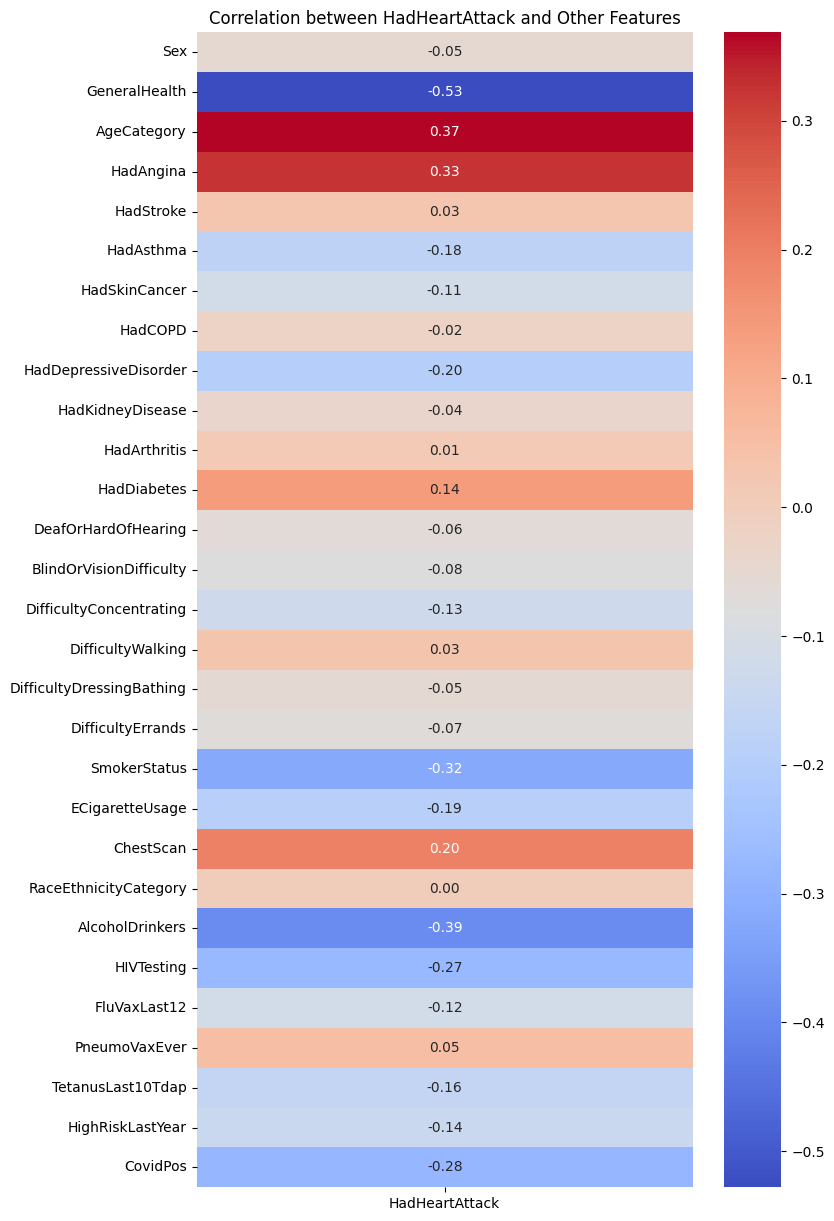

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

HadHeartAttack_corr = df_smote.corr()['HadHeartAttack']

HadHeartAttack_corr = HadHeartAttack_corr.drop('HadHeartAttack')

plt.figure(figsize=(8,15))   # Increase height

sns.heatmap(
    HadHeartAttack_corr.to_frame(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    cbar=True,
    annot_kws={'size':10}
)

plt.title('Correlation between HadHeartAttack and Other Features')
plt.show()

In [ ]:
df_smote.drop(['Sex','HadStroke','HadCOPD','HadKidneyDisease','HadArthritis','DeafOrHardOfHearing','PneumoVaxEver','BlindOrVisionDifficulty','DifficultyDressingBathing','DifficultyErrands','RaceEthnicityCategory'],axis=1,inplace=True)

In [ ]:
df_smote.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448858 entries, 0 to 448857
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   GeneralHealth            448858 non-null  int64
 1   AgeCategory              448858 non-null  int64
 2   HadAngina                448858 non-null  int64
 3   HadAsthma                448858 non-null  int64
 4   HadSkinCancer            448858 non-null  int64
 5   HadDepressiveDisorder    448858 non-null  int64
 6   HadDiabetes              448858 non-null  int64
 7   DifficultyConcentrating  448858 non-null  int64
 8   DifficultyWalking        448858 non-null  int64
 9   SmokerStatus             448858 non-null  int64
 10  ECigaretteUsage          448858 non-null  int64
 11  ChestScan                448858 non-null  int64
 12  AlcoholDrinkers          448858 non-null  int64
 13  HIVTesting               448858 non-null  int64
 14  FluVaxLast12             448858 non-

**outlier checking and removing:-**

<Axes: >

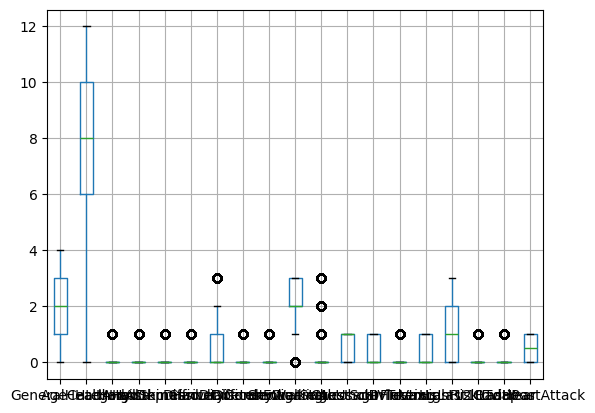

In [ ]:
df_smote.boxplot()

In [ ]:
def remove_outliers_iqr(df_smote,exclude_column):
  for col in df_smote.columns:
    if col == exclude_column:
      continue
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR

    df_smote=df_smote[(df_smote[col]>=lower_bound) & (df_smote[col]<=upper_bound)]
  return df_smote

  df_smote_cleaned= remove_outliers_iqr(df_smote,exclude_column='HadHeartAttack')
  df_smote=df_smote_cleaned

In [ ]:
df_smote.shape

(448858, 19)

**Data scaling**

In [ ]:
df_smote

,GeneralHealth,AgeCategory,HadAngina,HadAsthma,HadSkinCancer,HadDepressiveDisorder,HadDiabetes,DifficultyConcentrating,DifficultyWalking,SmokerStatus,ECigaretteUsage,ChestScan,AlcoholDrinkers,HIVTesting,FluVaxLast12,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartAttack
0,1,11,1,1,1,0,2,0,1,2,0,1,0,0,0,0,0,1,0
1,3,9,0,0,0,0,0,0,0,2,0,0,0,0,1,1,0,0,0
2,4,8,0,0,0,0,0,0,0,3,0,0,1,0,0,2,0,0,0
3,3,10,0,0,0,0,2,0,0,2,0,0,0,0,1,2,0,0,0
4,2,6,0,0,0,0,0,0,0,3,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448853,1,8,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1
448854,0,8,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1
448855,1,7,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,0,1
448856,1,7,0,0,0,0,0,0,0,2,0,1,0,0,1,0,0,0,1


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features=['GeneralHealth','AgeCategory','HadAngina','HadAsthma','HadSkinCancer','HadDepressiveDisorder','HadDiabetes','DifficultyConcentrating','DifficultyWalking','SmokerStatus','ECigaretteUsage','ChestScan','AlcoholDrinkers','HIVTesting','FluVaxLast12','TetanusLast10Tdap','HighRiskLastYear','CovidPos']

scaler=MinMaxScaler()

scaled_data=scaler.fit_transform(df_smote[features])

scaled_df_smote= pd.DataFrame(scaled_data,columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x=df_smote[['GeneralHealth','AgeCategory','HadAngina','HadAsthma','HadSkinCancer','HadDepressiveDisorder','HadDiabetes','DifficultyConcentrating','DifficultyWalking','SmokerStatus','ECigaretteUsage','ChestScan','AlcoholDrinkers','HIVTesting','FluVaxLast12','TetanusLast10Tdap','HighRiskLastYear','CovidPos']]
y=df_smote['HadHeartAttack']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=40)

model=LogisticRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy= accuracy_score(y_test,y_pred)
print(f'Baseline model accuracy:{accuracy:2f}')

Baseline model accuracy:0.862086


# **Project Conclusion**

This project focused on predicting heart attacks using a healthcare dataset containing demographic, medical, and lifestyle information. Exploratory Data Analysis (EDA) was performed to understand the data, identify patterns, and analyze relationships between features and the target variable (HadHeartAttack).

Data preprocessing techniques such as encoding and class balancing using SMOTE were applied to prepare the dataset for machine learning. Various health-related factors including age, general health, smoking status, diabetes, stroke history, and other medical conditions were analyzed for prediction.

A machine learning classification model was developed and achieved an accuracy of 86.20%, showing good performance in predicting heart attack cases. The project demonstrates how machine learning can support early health risk prediction and assist in healthcare decision-making.